# Mandatory Practical Work 01
Leandros Giagiozis / giagilea@students.zhaw.ch <br>
Pascal Kern / kernpas1@students.zhaw.ch

In [2]:
# We have to use wandb version 0.25.0 since there are bugs with the latest version
import wandb
print(wandb.__version__)

0.25.0


In [4]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor, Normalize, Compose
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt

import wandb

In [5]:
device = None
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

cpu


## Loading Data

In [5]:
# 64x64 data
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform
)

### Normalization

leads to faster and more stable training. Only with training data.

In [6]:
loader = DataLoader(train_data, batch_size=64, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
total_samples = 0

for images, _ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)  # flatten H and W
    mean += images.mean(dim=2).sum(dim=0)
    std += images.std(dim=2).sum(dim=0)
    total_samples += batch_size

mean /= total_samples
std /= total_samples
print(f"Mean: {mean}")
print(f"Std:  {std}")

Mean: tensor([0.4965, 0.4792, 0.3941])
Std:  tensor([0.2008, 0.1974, 0.2012])


### Augmented Data
Every epoch each image looks slightly different to the model, artificially expanding the dataset and forcing the model to focus on the animal's features rather than memorizing exact pixel positions, orientations, or lighting conditions.

In [7]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

transform_augmented = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.RandomCrop(64, padding=2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

train_data = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform
)

train_data_augmented = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform_augmented
)

val_data = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/validate",
    transform=transform
)

In [8]:
print("Train samples:", len(train_data))
print("Val samples:", len(val_data))
print(train_data.classes)

Train samples: 24000
Val samples: 6000
['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']


In [9]:
image, label = train_data[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 64, 64])
Label: 0


In [10]:
print("Min pixel value:", image.min())
print("Max pixel value:", image.max())

Min pixel value: tensor(-2.4332)
Max pixel value: tensor(3.0112)


C:\Users\leand\AppData\Local\Temp\ipykernel_21956\4286855250.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean_t = torch.tensor(mean).view(3, 1, 1)
C:\Users\leand\AppData\Local\Temp\ipykernel_21956\4286855250.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std_t = torch.tensor(std).view(3, 1, 1)


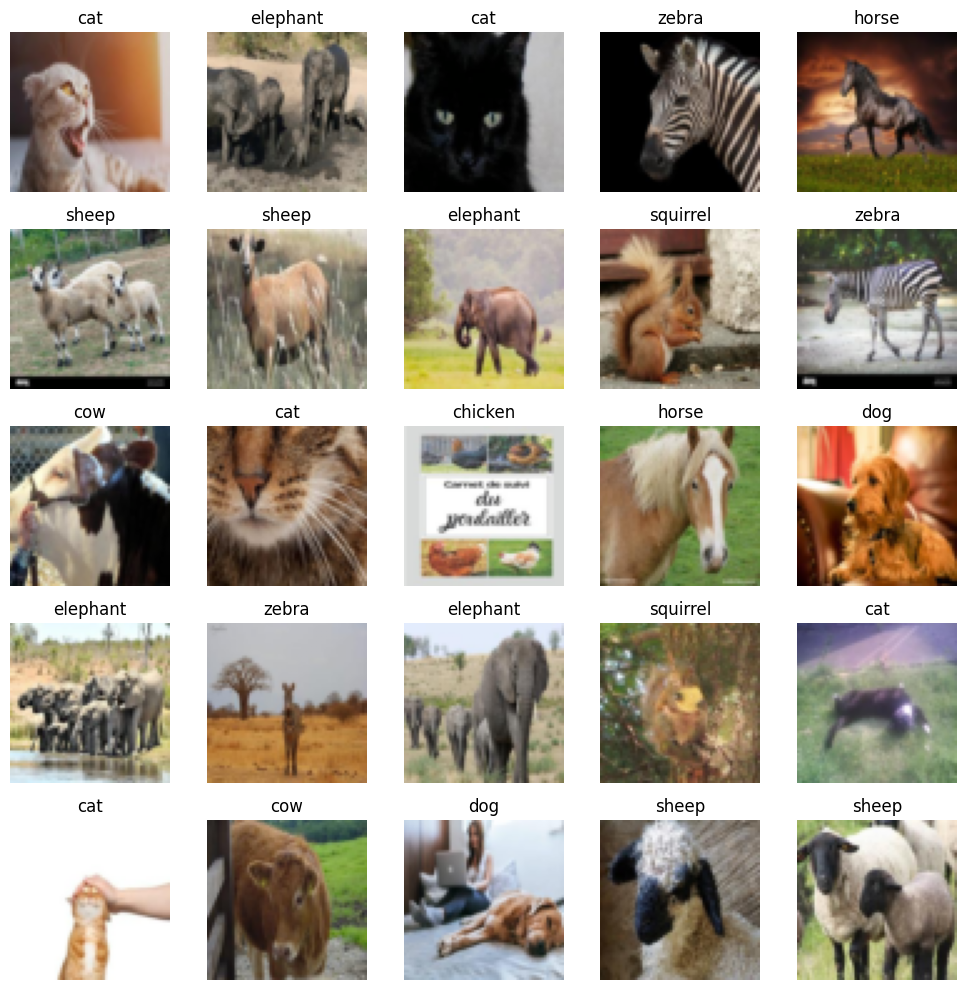

In [11]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

loader = DataLoader(train_data, batch_size=25, shuffle=True)
images, labels = next(iter(loader))

# denormalize
mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)
images_denorm = images * std_t + mean_t
images_denorm = images_denorm.clamp(0, 1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i in range(25):
    img = images_denorm[i].permute(1, 2, 0)

    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(train_data.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Models

Idea: Each new layer essentially performs a similar transformation on the same features of the last Layer, resulting in redundant computations rather than richer abstractions. Increased depth must be paired with growing filter counts, allowing each layer to build progressively more abstract and diverse feature representations.

This is why we went with...

### Shallow Model

In [12]:
class shallowModel(torch.nn.Module):

    def __init__(self, units = 128, filter = 16, n_classes = 10):
        super(shallowModel, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1                                                # 3, 64, 64 input
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),    # 16, 64, 64
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 16, 32, 32

            # Flatten and first Dense / Linear Layer
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter, units),
            torch.nn.ReLU(),

            # Output Layer
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)


In [13]:
# summary

model = shallowModel().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
 AdaptiveAvgPool2d-4             [-1, 16, 1, 1]               0
           Flatten-5                   [-1, 16]               0
            Linear-6                  [-1, 128]           2,176
              ReLU-7                  [-1, 128]               0
            Linear-8                   [-1, 10]           1,290
Total params: 3,914
Trainable params: 3,914
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 1.13
Params size (MB): 0.01
Estimated Total Size (MB): 1.19
----------------------------------------------------------------


### Medium Model

In [14]:
class mediumModel(torch.nn.Module):

    def __init__(self, units = 128, filter = 16, n_classes = 10):
        super(mediumModel, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1                                                # 3, 64, 64 input
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),    # 16, 64, 64
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 16, 32, 32

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),  # 32, 32, 32
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 32, 16, 16

            # Flatten and first Dense / Linear Layer
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*2, units),
            torch.nn.ReLU(),

            # Output Layer
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)


In [15]:
# summary

model = mediumModel().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           4,640
              ReLU-5           [-1, 32, 32, 32]               0
         MaxPool2d-6           [-1, 32, 16, 16]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
           Flatten-8                   [-1, 32]               0
            Linear-9                  [-1, 128]           4,224
             ReLU-10                  [-1, 128]               0
           Linear-11                   [-1, 10]           1,290
Total params: 10,602
Trainable params: 10,602
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/ba

### Deep Model

In [16]:
class deepModel(torch.nn.Module):

    def __init__(self, units = 128, filter = 16, n_classes = 10):
        super(deepModel, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1                                                # 3, 64, 64 input
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),    # 16, 64, 64
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 16, 32, 32

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),  # 32, 32, 32
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 32, 16, 16

            # Layer 3
            torch.nn.Conv2d(filter*2, filter*4, kernel_size=3, padding=1), # 64, 16, 16
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),                # 64, 8, 8

            # Flatten and first Dense / Linear Layer
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*4, units),
            torch.nn.ReLU(),

            # Output Layer
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)


In [17]:
model = deepModel().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           4,640
              ReLU-5           [-1, 32, 32, 32]               0
         MaxPool2d-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]          18,496
              ReLU-8           [-1, 64, 16, 16]               0
         MaxPool2d-9             [-1, 64, 8, 8]               0
AdaptiveAvgPool2d-10             [-1, 64, 1, 1]               0
          Flatten-11                   [-1, 64]               0
           Linear-12                  [-1, 128]           8,320
             ReLU-13                  [-1, 128]               0
           Linear-14                   

### Deep Model2

In [18]:
class deepModel2(torch.nn.Module):

    def __init__(self, units = 128, filter = 16, n_classes = 10):
        super(deepModel2, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1                                                # 3, 64, 64 input
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),    # 16, 64, 64
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 16, 32, 32

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),  # 32, 32, 32
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),             # 32, 16, 16

            # Layer 3
            torch.nn.Conv2d(filter*2, filter*4, kernel_size=3, padding=1), # 64, 16, 16
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),                # 64, 8, 8

            # Layer 4
            torch.nn.Conv2d(filter*4, filter*8, kernel_size=3, padding=1), # 128, 16, 16
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),                # 128, 8, 8

            # Flatten and first Dense / Linear Layer
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*8, units),
            torch.nn.ReLU(),

            # Output Layer
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)


In [19]:
model = deepModel2().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           4,640
              ReLU-5           [-1, 32, 32, 32]               0
         MaxPool2d-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]          18,496
              ReLU-8           [-1, 64, 16, 16]               0
         MaxPool2d-9             [-1, 64, 8, 8]               0
           Conv2d-10            [-1, 128, 8, 8]          73,856
             ReLU-11            [-1, 128, 8, 8]               0
        MaxPool2d-12            [-1, 128, 4, 4]               0
AdaptiveAvgPool2d-13            [-1, 128, 1, 1]               0
          Flatten-14                  [

## Training Loop

In [20]:
def train_eval(model, optimizer, nepochs, batch_size, training_data, validation_data, device, log_wandb = False, patience=10, min_delta=0.0):
    """
    Performs the training of a model with given learning rate (lr),
    number of epochs (nepochs), batchsize (batch_size) and training and validation data.
    Suitable data loaders are instantiated for the training and validation datasets.
    Keep book about cost and accuracy (per epoch) for both training and validation set.
    """
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []

    model = model.to(device)
    cost_ce = torch.nn.CrossEntropyLoss().to(device)

    train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(validation_data, batch_size=batch_size, shuffle=False)

    # early stopping
    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(nepochs):
        model.train()
        size = len(train_loader.dataset)
        nbatches = len(train_loader)
        cost, acc = 0.0, 0.0
        for batch, (X, Y) in enumerate(train_loader):
            X,Y = X.to(device),Y.to(device)
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

            # gradient, parameter update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        cost /= nbatches
        acc /= size

        model.eval()
        size_test = len(val_loader.dataset)
        nbatches_test = len(val_loader)
        cost_test, acc_test = 0.0, 0.0
        with torch.no_grad():
            for X, Y in val_loader:
                X,Y = X.to(device),Y.to(device)
                pred = model(X)
                cost_test += cost_ce(pred, Y).item()
                acc_test += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
        cost_test /= nbatches_test
        acc_test /= size_test
        print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))

        if log_wandb:
            wandb.log({
                "epoch": epoch,
                "train_loss": cost,
                "train_acc": acc,
                "val_loss": cost_test,
                "val_acc": acc_test
            })

        cost_hist.append(cost)
        cost_hist_test.append(cost_test)
        acc_hist.append(acc)
        acc_hist_test.append(acc_test)

        # Early Stopping
        if cost_test < best_val_loss - min_delta:
            best_val_loss = cost_test
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    # restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

## Training

In [20]:
models = {
    "shallow": (shallowModel, 1),
    "medium": (mediumModel, 2),
    "deep": (deepModel, 3),
    "deep2": (deepModel, 4)
}

for name, (ModelClass, n_layers) in models.items():
    wandb.init(
        project="PW01",
        name=name + "_width",
        config={
            "lr": 0.05,
            "momentum": 0.9,
            "batch_size": 64,
            "epochs": 60,
            "filters": 16,
            "units": 128,
            "Model": name,
            "Layers": n_layers
        }
    )

    config = wandb.config

    model = ModelClass()
    optimizer = torch.optim.SGD(params=model.parameters(), lr=config["lr"], momentum=config["momentum"])
    train_eval(model, optimizer, config["epochs"], config["batch_size"], train_data, val_data, device, log_wandb = True, patience=40)

    wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\leand\_netrc.
wandb: Currently logged in as: leandros-giagiozis (leandros-giagiozis-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 2.220100, 0.177667, 2.146205, 0.224167
Epoch 1: 2.092325, 0.243750, 2.031135, 0.270833
Epoch 2: 2.029533, 0.274167, 2.017822, 0.276833
Epoch 3: 1.969327, 0.297208, 1.939333, 0.313500
Epoch 4: 1.929014, 0.310292, 1.868719, 0.339500
Epoch 5: 1.879226, 0.329333, 1.817860, 0.356500
Epoch 6: 1.846323, 0.341875, 1.819887, 0.351500
Epoch 7: 1.809324, 0.355000, 1.808480, 0.356833
Epoch 8: 1.771578, 0.370042, 1.750349, 0.381000
Epoch 9: 1.752193, 0.378458, 1.775557, 0.367833
Epoch 10: 1.745872, 0.379917, 1.830483, 0.368167
Epoch 11: 1.734308, 0.381375, 1.732143, 0.386000
Epoch 12: 1.710133, 0.392292, 1.739702, 0.386000
Epoch 13: 1.707074, 0.394417, 1.757978, 0.381667
Epoch 14: 1.698368, 0.399500, 1.686670, 0.400000
Epoch 15: 1.683114, 0.401542, 1.714301, 0.397500
Epoch 16: 1.669711, 0.413208, 1.669908, 0.403167
Epoch 17: 1.666720, 0.409125, 1.712807, 0.399000
Epoch 18: 1.654748, 0.414042, 1.627797, 0.417833
Epoch 19: 1.653485, 0.413292, 1.645214, 0.414333
Epoch 20: 1.640289, 0.414042, 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 59: 1.517470, 0.465792, 1.584278, 0.444667


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
train_acc,▁▃▃▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████████████
train_loss,█▇▆▆▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▄▄▅▅▆▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█▇▇▇█▇▇▇█▇███████
val_loss,█▇▆▆▅▄▄▃▃▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂▁▁▂▂▂▁▂▁▁▁▁▁
epoch,59
train_acc,0.46579
train_loss,1.51747
val_acc,0.44467
val_loss,1.58428


...

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train_acc,▁▂▃▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████
train_loss,█▇▆▅▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▄▄▅▆▇▇▇▇▇▇█▇█▇███████████████▇▇▇██████
val_loss,█▅▄▄▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▂▂▁▁▁▂▂▁▂▂▂▂▂▃▃▂▂▂▃▃▃
epoch,59
train_acc,0.73979
train_loss,0.74505
val_acc,0.56967
val_loss,1.53596


Epoch 0: 2.244248, 0.161208, 2.224700, 0.177667
Epoch 1: 2.086520, 0.239750, 1.946927, 0.291167
Epoch 2: 1.885271, 0.328708, 1.782409, 0.354667
Epoch 3: 1.739165, 0.379125, 1.666858, 0.409000
Epoch 4: 1.632702, 0.425625, 1.567296, 0.439333
Epoch 5: 1.551589, 0.452250, 1.546185, 0.445000
Epoch 6: 1.493708, 0.476875, 1.486094, 0.466333
Epoch 7: 1.420200, 0.506833, 1.424963, 0.497000
Epoch 8: 1.369416, 0.518625, 1.424531, 0.498000
Epoch 9: 1.314926, 0.540583, 1.317117, 0.543833
Epoch 10: 1.285376, 0.548792, 1.355350, 0.523167
Epoch 11: 1.232022, 0.572125, 1.270546, 0.554667
Epoch 12: 1.217311, 0.575417, 1.362399, 0.532833
Epoch 13: 1.177228, 0.590875, 1.291903, 0.546000
Epoch 14: 1.157256, 0.595625, 1.292163, 0.554000
Epoch 15: 1.132228, 0.606875, 1.254846, 0.571500
Epoch 16: 1.109181, 0.614708, 1.210226, 0.580500
Epoch 17: 1.098151, 0.618000, 1.241073, 0.563000
Epoch 18: 1.069880, 0.627458, 1.212545, 0.583333
Epoch 19: 1.055702, 0.635292, 1.245331, 0.576500
Epoch 20: 1.042591, 0.640167, 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 56: 0.752300, 0.739833, 1.445127, 0.578667
Early stopping triggered at epoch 56.


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
train_acc,▁▂▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇███████████████
train_loss,█▇▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▄▄▅▆▆▇▆▇▇▇██▇█▇██████▇████▇███▇▇██▇▇▇█
val_loss,█▆▅▄▃▂▂▂▁▂▁▁▁▁▁▁▁▁▂▁▂▁▂▂▂▂▂▂▂▂▂▂▂▂▃▃▄▃▃▃
epoch,56
train_acc,0.73983
train_loss,0.7523
val_acc,0.57867
val_loss,1.44513


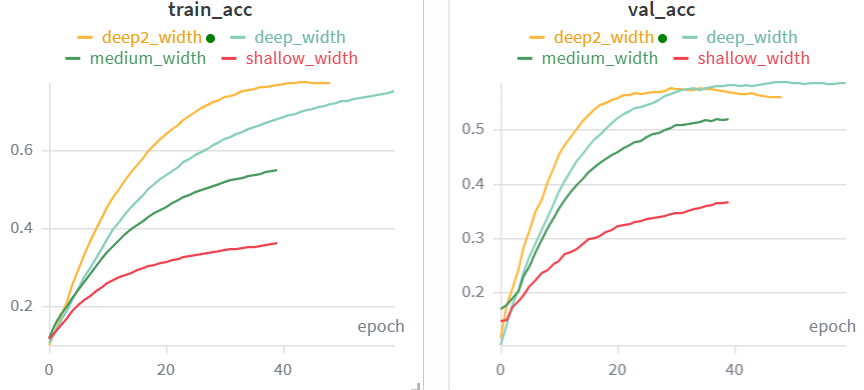

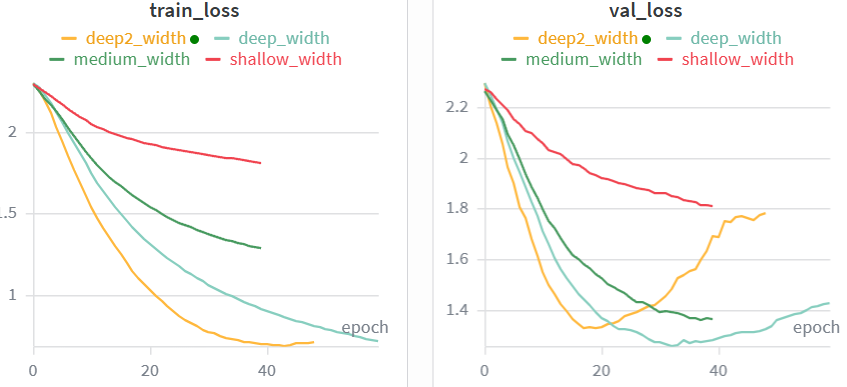

## a) Benefit of Depth
The potential of the models increases with depth. Multiple layers allow the model to work on different levels of abstraction and learn hierarchical features.

In the first layer the model might recognizes features like edges, corners, and color gradients. In the second layer the model might combine them into more structured patterns and in the third layer the model might begin to detect parts like eyes, ears, snouts, and limbs.

This is probably why the deep model performed better than the shallow one, since a single layer can only ever see raw edges, it has no mechanism to combine them into meaningful concepts. Each additional layer gives the model one more level of abstraction to work with.

That beeing said, we also see underfitting in the shallow model, a good fit in the medium one, the start of overfitting in the deep one and clear overfitting in the deep2 one. We will get back to that in Part c).

### Decision:
For further Exercises like Hyperparametertuning we use the deep Model since it is the most promessing and we didnt see an improvement with adding another layer in the deep2 Model.

## c) Show models that overfit and underfit and explain the reasons for that

Looking at our previously created Models below, we see underfitting with the shallow model. As mentioned in a) we assume the reason for unterfitting is the lack of model complexity and depth. We can see that the model even has trouble learning the training data. With just one single layer it can only see raw edges, it has no mechanism to combine them into meaningful concepts.

Underfitting can be cause by the following:
- Model too simple
- Training stopped too early (not enough epochs)
- Too strong regularisation
- Poor optimisation (e.g too low learningrate)

An overfitting model on the other hand is deep2. This becomes especially apparent when looking at the val_loss, which decreases but then starts rising after 20 epochs. Also the training accuracy lays at around 70% while the validation accuracy lays around 55% and is decreasing. A clear sign of overfitting.
Resons for this will be the model complexity in regards to the dataset size, aswell as not having regularization and training for too many epochs.

Overfitting can be caused by the following:
- Not enough training data (the model memorises instead of generalising)
- Model capacity too high  
- Training for too many epochs
- Too weak regularisation

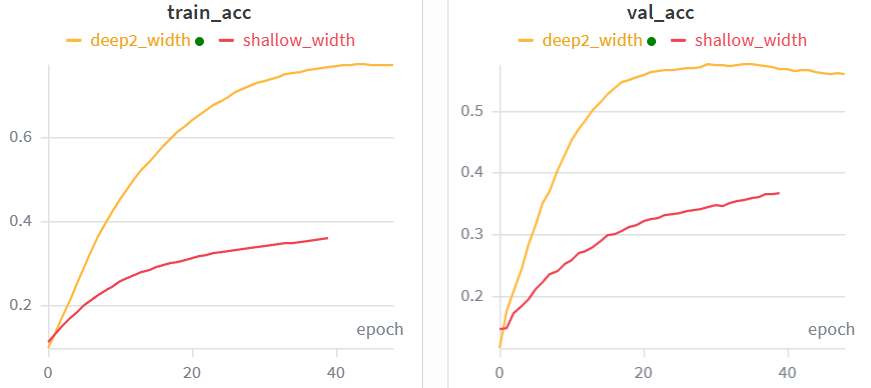

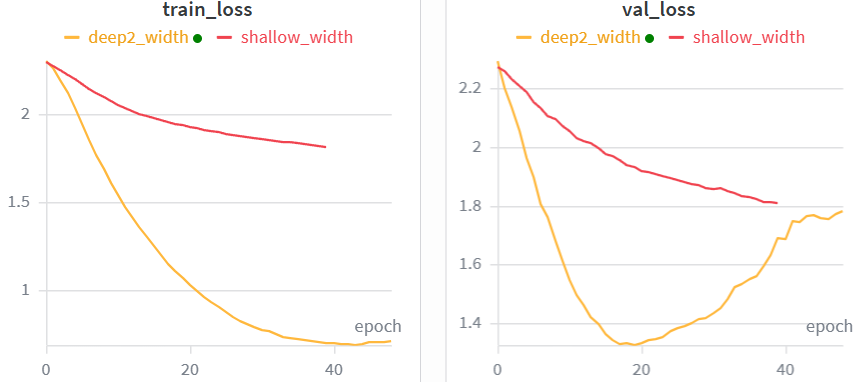

## c) Regularization

For this we take our most promising model (deep) which is also starting to overfit, and apply different regularization techniques to combat this. Namely Dropout, L2 regularization (weight decay), data augmentation and early stopping.

In [21]:
class deepModel_drop(torch.nn.Module):

    def __init__(self, units=128, filter=16, n_classes=10, dropout_conv=0.2, dropout_fc=0.5):
        super(deepModel_drop, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 3
            torch.nn.Conv2d(filter*2, filter*4, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Flatten and Dense
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*4, units),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_fc),

            # Output
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)

In [22]:
model = deepModel_drop().to(device)
from torchsummary import summary
summary(model, (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
         Dropout2d-4           [-1, 16, 32, 32]               0
            Conv2d-5           [-1, 32, 32, 32]           4,640
              ReLU-6           [-1, 32, 32, 32]               0
         MaxPool2d-7           [-1, 32, 16, 16]               0
         Dropout2d-8           [-1, 32, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]          18,496
             ReLU-10           [-1, 64, 16, 16]               0
        MaxPool2d-11             [-1, 64, 8, 8]               0
        Dropout2d-12             [-1, 64, 8, 8]               0
AdaptiveAvgPool2d-13             [-1, 64, 1, 1]               0
          Flatten-14                   

In [23]:
models = {
    "Data augment":  (deepModel,      train_data_augmented),
    "Drop":          (deepModel_drop, train_data),
    "L2":            (deepModel,      train_data),
    "Data augment, Drop and L2":   (deepModel_drop, train_data_augmented),
}

for name, (ModelClass, t_data) in models.items():

    weight_decay = 1e-4 if "L2" in name else 0.0

    wandb.init(
        project="PW01",
        name=name + " + early_stop",
        config={
            "lr": 0.02,
            "momentum": 0.9,
            "batch_size": 64,
            "epochs": 100,
            "units": 128,
            "filters": 16,
            "dropout_conv": 0.1,
            "dropout_fc": 0.3,
            "weight_decay": weight_decay,
            "patience": 5
        }
    )

    config = wandb.config

    if "Drop" in name:
        model = ModelClass(units=config["units"],
                          filter=config["filters"],
                          dropout_conv=config["dropout_conv"],
                          dropout_fc=config["dropout_fc"])
    else:
        model = ModelClass(units=config["units"],
                          filter=config["filters"])

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=config["weight_decay"]
    )

    train_eval(model, optimizer, config["epochs"], config["batch_size"],
               t_data, val_data, device, patience=config["patience"],
               log_wandb=True, min_delta=0.0)

    wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\leand\_netrc.
wandb: Currently logged in as: leandros-giagiozis (leandros-giagiozis-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 2.262767, 0.154792, 2.190709, 0.205000
Epoch 1: 2.112490, 0.231958, 2.013014, 0.266500
Epoch 2: 1.960113, 0.294250, 1.877077, 0.316833
Epoch 3: 1.852107, 0.333708, 1.711534, 0.382833
Epoch 4: 1.743829, 0.376833, 1.699961, 0.393500
Epoch 5: 1.645721, 0.420375, 1.541776, 0.458000
Epoch 6: 1.581432, 0.444792, 1.472459, 0.490833
Epoch 7: 1.511232, 0.467875, 1.561576, 0.443833
Epoch 8: 1.465166, 0.484667, 1.352313, 0.527167
Epoch 9: 1.409918, 0.506000, 1.360814, 0.527833
Epoch 10: 1.357310, 0.520375, 1.346313, 0.521500
Epoch 11: 1.315107, 0.536083, 1.234858, 0.564667
Epoch 12: 1.270798, 0.554000, 1.224186, 0.569500
Epoch 13: 1.248026, 0.562833, 1.230962, 0.567333
Epoch 14: 1.222999, 0.575750, 1.185822, 0.588000
Epoch 15: 1.194979, 0.586292, 1.148460, 0.593500
Epoch 16: 1.163021, 0.595417, 1.141751, 0.592833
Epoch 17: 1.150333, 0.597917, 1.145031, 0.591333
Epoch 18: 1.125332, 0.607833, 1.111418, 0.607167
Epoch 19: 1.120290, 0.610167, 1.120326, 0.609333
Epoch 20: 1.100855, 0.620917, 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 39: 0.922778, 0.684542, 1.005916, 0.657167
Early stopping triggered at epoch 39.


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▂▃▃▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████
val_loss,█▇▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,39
train_acc,0.68454
train_loss,0.92278
val_acc,0.65717
val_loss,1.00592


...

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
train_acc,▁▂▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇████████
train_loss,█▇▆▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▂▃▃▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇████████████
val_loss,█▇▆▆▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▂▁▂▂▂▁▂
epoch,31
train_acc,0.72313
train_loss,0.79181
val_acc,0.61483
val_loss,1.16457


Epoch 0: 2.286105, 0.125208, 2.242804, 0.177500
Epoch 1: 2.203469, 0.193500, 2.117286, 0.237333
Epoch 2: 2.099570, 0.239917, 2.014502, 0.277000
Epoch 3: 2.009368, 0.273125, 1.904849, 0.317500
Epoch 4: 1.935022, 0.300333, 1.828976, 0.354500
Epoch 5: 1.877630, 0.324833, 1.746945, 0.378333
Epoch 6: 1.834356, 0.342917, 1.724618, 0.384333
Epoch 7: 1.799806, 0.353667, 1.672520, 0.413333
Epoch 8: 1.771954, 0.368708, 1.642000, 0.428167
Epoch 9: 1.769947, 0.372000, 1.649458, 0.421333
Epoch 10: 1.730348, 0.389792, 1.559624, 0.457000
Epoch 11: 1.692073, 0.400125, 1.538300, 0.459500
Epoch 12: 1.667677, 0.411458, 1.540647, 0.465333
Epoch 13: 1.648080, 0.419708, 1.475153, 0.494333
Epoch 14: 1.617850, 0.431417, 1.459212, 0.503833
Epoch 15: 1.602094, 0.434875, 1.448444, 0.494000
Epoch 16: 1.588459, 0.443500, 1.413648, 0.505667
Epoch 17: 1.562264, 0.452125, 1.404063, 0.512000
Epoch 18: 1.550338, 0.452125, 1.366817, 0.519333
Epoch 19: 1.536575, 0.457958, 1.364888, 0.522500
Epoch 20: 1.532760, 0.465875, 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 66: 1.299410, 0.554292, 1.131295, 0.602333
Early stopping triggered at epoch 66.


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▂▃▃▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train_loss,█▇▇▆▆▅▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
val_loss,█▇▇▆▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,66
train_acc,0.55429
train_loss,1.29941
val_acc,0.60233
val_loss,1.13129


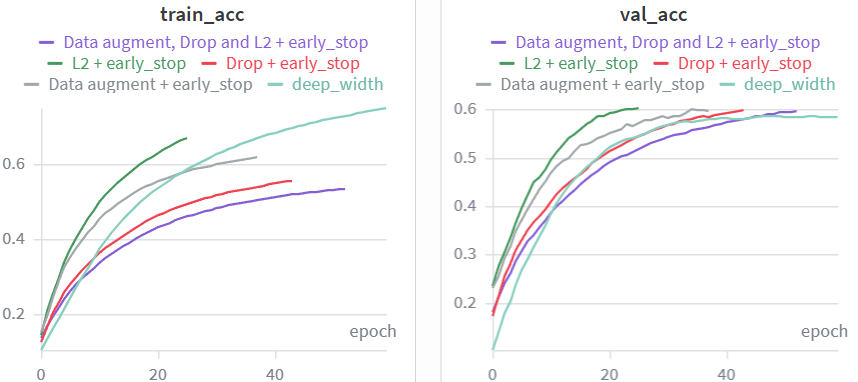

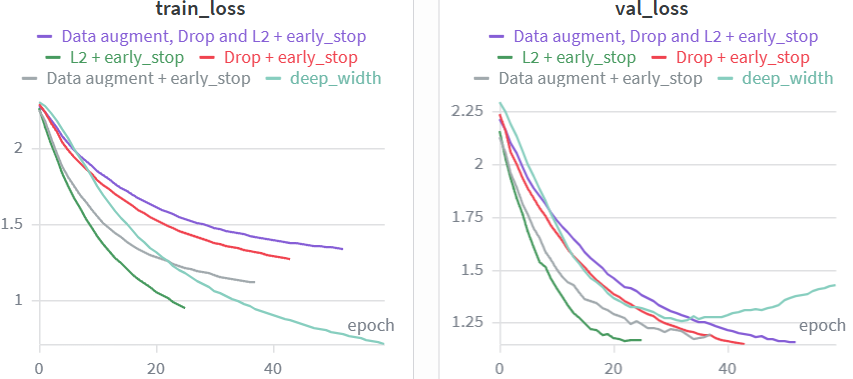

In the above graphs we can see some interesting things. First of all we can say that all of the Regularization techniques did what they were supposed to, keep our model **deep_width** from overfitting, which is clearly visible with the training and validation loss. Also it lead to some performance improvements which is clearly visible in val_loss.

**Early Stopping** is our favourit, which we applied to all the trainings. It allows us to reduce the risk of underfitting by enabiling us to set a high epoch without the risk of overfitting and at the same time reducing time by cutting out unnessecary epochs (If val_loss doesnt improve for 5 epochs training is aborded (This was a bit an aggressive value, later increased it to 10)).

**Dropout** introduces noise during training by randomly deactivating neurons, forcing the network to learn more robust features. This is also why validation accuracy is higher than training accuracy in our runs.

**L2** regularization penalizes large weights, which prevents the model from relying too heavily on any single feature. We might have set it too low since the gap between training and validation accuracy is still rather big with 7%, indicating the model is still slightly overfitting.

**Data augmentation** expands the training set by applying changes (flips, crops, rotations, etc.) to the existing samples. It performed well, but we learned to be careful with the values and early stopping, since validation loss can fluctuate at the beginning because the augmented training images might differ substantially from the validation data,potentially triggering early stopping, before the model has had a chance to improve.

**All the above together** appears to be overly agressive and over-regularize, since the training took the most epochs without any significant improvement in validation accuracy over the others.






## b) Hyperparameter tuning


In [46]:
run_configs = [
    {"name": "Run10_filter64_lr002_aug_L2",     "lr": 0.02,  "filters": 128, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 1e-4},
    {"name": "Run1_filter32",                   "lr": 0.02,  "filters": 32, "dropout_conv": 0.1,  "dropout_fc": 0.3, "augmented": False, "weight_decay": 0},
    {"name": "Run5_filter32_lr001_aug",         "lr": 0.01,  "filters": 32, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0},
    {"name": "Run2_filter64_lr002_aug",         "lr": 0.02,  "filters": 64, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0},
    {"name": "Run6_filter32_lr002_aug",         "lr": 0.02,  "filters": 32, "dropout_conv": 0.1,  "dropout_fc": 0.3, "augmented": True, "weight_decay": 0},  
    {"name": "Run8_filter128_lr002_aug",        "lr": 0.02,  "filters": 128, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0},
    {"name": "Run9_filter64_lr001_aug",         "lr": 0.01,  "filters": 64, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0},
]

for cfg in run_configs:
    train_data_used = train_data_augmented if cfg["augmented"] else train_data

    wandb.init(
        project="PW01",
        name=cfg["name"],
        config={
            **cfg,
            "momentum":     0.9,
            "batch_size":   64,
            "epochs":       200,
            "min_delta":    0.0,
            "patience":     10,
            "units":        128,
        }
    )

    config = wandb.config

    model = deepModel_drop(
        units=config["units"],
        filter=config["filters"],
        dropout_conv=config["dropout_conv"],
        dropout_fc=config["dropout_fc"]
    )

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=cfg["weight_decay"]
    )

    train_eval(model, optimizer, config["epochs"], config["batch_size"],
               train_data_used, val_data, device,
               patience=config["patience"],
               log_wandb=True,
               min_delta=config["min_delta"])

    wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁█
train_acc,▁█
train_loss,█▁
val_acc,▁█
val_loss,█▁
epoch,1
train_acc,0.25
train_loss,2.07549
val_acc,0.2825
val_loss,1.98013


Epoch 0: 2.246903, 0.159917, 2.165542, 0.216500
Epoch 1: 2.076437, 0.250500, 1.971798, 0.280333
Epoch 2: 1.940108, 0.300750, 1.806084, 0.348833
Epoch 3: 1.824703, 0.345750, 1.732618, 0.390000
Epoch 4: 1.732028, 0.386000, 1.604065, 0.429833
Epoch 5: 1.649504, 0.412500, 1.515552, 0.472333
Epoch 6: 1.563445, 0.449750, 1.418564, 0.507000
Epoch 7: 1.496419, 0.471250, 1.389390, 0.513167
Epoch 8: 1.447749, 0.489833, 1.250104, 0.559667
Epoch 9: 1.386823, 0.513125, 1.257254, 0.557000
Epoch 10: 1.338915, 0.530083, 1.234376, 0.567000
Epoch 11: 1.288681, 0.550417, 1.137031, 0.594500
Epoch 12: 1.262243, 0.559750, 1.112298, 0.605333
Epoch 13: 1.215575, 0.575833, 1.090785, 0.618333
Epoch 14: 1.194112, 0.585417, 1.113464, 0.604833
Epoch 15: 1.148425, 0.600208, 1.044612, 0.628333
Epoch 16: 1.130118, 0.607750, 1.016508, 0.639000
Epoch 17: 1.096535, 0.622167, 0.965612, 0.656667
Epoch 18: 1.072603, 0.629917, 0.969747, 0.665333
Epoch 19: 1.038115, 0.645958, 0.963244, 0.668333
Epoch 20: 1.016906, 0.654167, 

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
train_acc,▁▂▃▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▇▆▆▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇██▇████▇███████████
val_loss,█▇▆▆▅▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,61
train_acc,0.82637
train_loss,0.51164
val_acc,0.78333
val_loss,0.6544


Epoch 0: 2.265360, 0.141917, 2.196176, 0.202167
Epoch 1: 2.104200, 0.237042, 1.996108, 0.290167
Epoch 2: 1.975886, 0.290750, 1.884691, 0.324000
Epoch 3: 1.875564, 0.324000, 1.795910, 0.353333
Epoch 4: 1.803439, 0.355167, 1.737566, 0.379000
Epoch 5: 1.748508, 0.377417, 1.640602, 0.429167
Epoch 6: 1.688914, 0.403833, 1.624939, 0.431000
Epoch 7: 1.636995, 0.424417, 1.526151, 0.474167
Epoch 8: 1.580016, 0.443667, 1.427343, 0.499833
Epoch 9: 1.534172, 0.460500, 1.422544, 0.486667
Epoch 10: 1.489704, 0.478375, 1.331557, 0.525167
Epoch 11: 1.461332, 0.489625, 1.352417, 0.525833
Epoch 12: 1.411248, 0.507292, 1.296702, 0.547333
Epoch 13: 1.379490, 0.517042, 1.266854, 0.549667
Epoch 14: 1.350571, 0.526083, 1.205670, 0.578333
Epoch 15: 1.331780, 0.535458, 1.241612, 0.558333
Epoch 16: 1.302195, 0.544958, 1.161488, 0.586833
Epoch 17: 1.271642, 0.558625, 1.118788, 0.610167
Epoch 18: 1.252963, 0.564917, 1.196331, 0.569667
Epoch 19: 1.220091, 0.575625, 1.146776, 0.600000
Epoch 20: 1.195697, 0.580458, 

...

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇██
train_acc,▁▂▃▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▃▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██████▇██████████
val_loss,██▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,63
train_acc,0.84329
train_loss,0.46158
val_acc,0.80083
val_loss,0.61923


Epoch 0: 2.286628, 0.129833, 2.238016, 0.192667
Epoch 1: 2.194461, 0.193292, 2.121183, 0.231667
Epoch 2: 2.083932, 0.249583, 1.990679, 0.272833
Epoch 3: 2.004212, 0.279167, 1.924029, 0.315333
Epoch 4: 1.919672, 0.303875, 1.816309, 0.351333
Epoch 5: 1.856467, 0.337458, 1.778677, 0.368500
Epoch 6: 1.800160, 0.359125, 1.687626, 0.413000
Epoch 7: 1.751253, 0.380042, 1.642400, 0.423500
Epoch 8: 1.700823, 0.394250, 1.562796, 0.457167
Epoch 9: 1.650928, 0.416208, 1.532545, 0.468833
Epoch 10: 1.614292, 0.434083, 1.476021, 0.486333
Epoch 11: 1.567424, 0.448583, 1.447125, 0.500500
Epoch 12: 1.533022, 0.463917, 1.387750, 0.508833
Epoch 13: 1.501889, 0.471833, 1.383501, 0.517167
Epoch 14: 1.473936, 0.480375, 1.378943, 0.526667
Epoch 15: 1.429158, 0.500208, 1.320407, 0.530000
Epoch 16: 1.399890, 0.508417, 1.272868, 0.554500
Epoch 17: 1.372752, 0.519292, 1.223792, 0.582167
Epoch 18: 1.347984, 0.528708, 1.204182, 0.586000
Epoch 19: 1.319882, 0.539208, 1.169175, 0.591333
Epoch 20: 1.303935, 0.544458, 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 114: 0.567856, 0.807667, 0.634911, 0.791500
Early stopping triggered at epoch 114.


epoch,▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▂▂▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████████
train_loss,██▇▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇███▇███████████████
val_loss,█▇▆▅▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,114
train_acc,0.80767
train_loss,0.56786
val_acc,0.7915
val_loss,0.63491


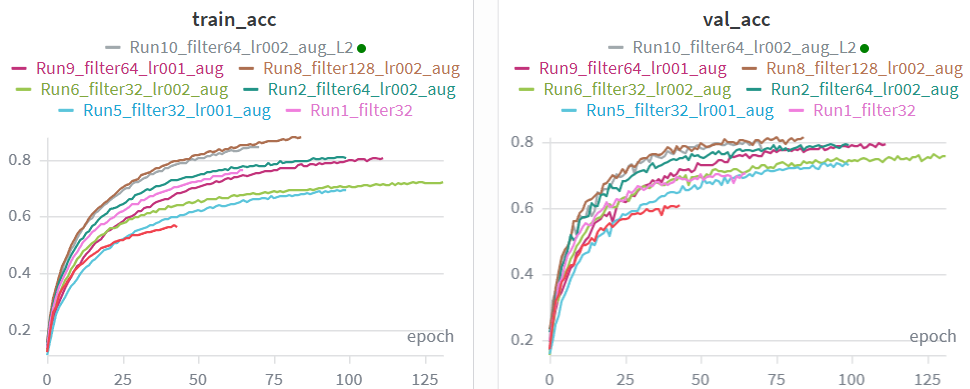

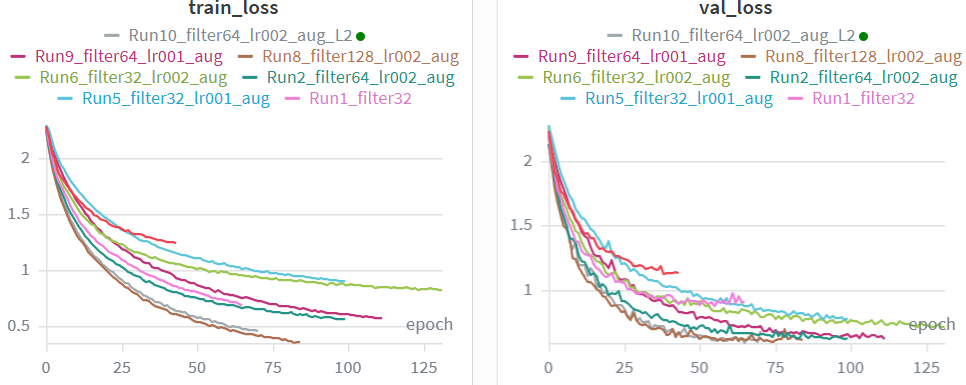

How good is your perception of colour?

We can clearly see the importance of hyperparameter tuning. With just a few experiments we were able to find models that outperform our best one in **Red** vastly. 
Parameters that we experimented with were learningrate, the amount of filters and regularizations. We did this by selectivly changing one parameter at a time and building on the better model.

Our Steps:
- We increased the amount of filter from our **Red Model** from 16 to 32, with a learningrate of 0.02 and no data augmentation (**Pink Model**)
- We added data augmentation to our **Pink Model**, which gave us the **light Green Model** with better validation loss and a general better fit.
- We testes a learning rate of 0.01 instead of the 0.02 (**light Blue Model**) and saw no improvements over the previous Model
- We increased the amount of filters from 32 to 64 in our **Turquoise Model** and saw rise in performance and an overall good fit.
- We tried another increase in filter to 128 with our **Brown Model** but saw no significant validation loss improvement, and the start of overfitting.

**Decision**:
We decided to continue our work with the **Turquoise Model** since the no other Model was significantly better and it is overall a good fit.

## Optuna for Hyperparameter Tuning

In [37]:
import optuna
print(optuna.__version__)

4.8.0


c:\Users\leand\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [44]:
def objective(trial):
    filters = trial.suggest_categorical("filters", [32, 64, 128])
    augmented = trial.suggest_categorical("augmented", [False, True])
    lr = trial.suggest_float("lr", 0.008, 0.03, log=True)

    use_l2 = trial.suggest_categorical("use_l2", [False, True])
    if use_l2:
        weight_decay = trial.suggest_float("weight_decay", 5e-6, 5e-4, log=True)
    else:
        weight_decay = 0.0

    train_data_used = train_data_augmented if augmented else train_data

    model = deepModel_drop(
        units=128,
        filter=filters,
        dropout_conv=0.1,
        dropout_fc=0.3
    )

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay
    )

    result = train_eval(
        model, optimizer,
        50, 64,
        train_data_used, val_data, device,
        patience=5,
        log_wandb=False,
        min_delta=0.0
    )

    val_losses = result[1]
    return min(val_losses)

In [45]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

[I 2026-03-28 14:01:57,237] A new study created in memory with name: no-name-597dafb4-e96d-4c03-80ba-a916205e447c


Epoch 0: 2.270493, 0.143583, 2.199149, 0.217167
Epoch 1: 2.141179, 0.222167, 2.053714, 0.255833
Epoch 2: 2.022187, 0.270958, 1.919069, 0.317500
Epoch 3: 1.923473, 0.310333, 1.810573, 0.358667
Epoch 4: 1.843518, 0.334208, 1.753624, 0.368333
Epoch 5: 1.771834, 0.368583, 1.690903, 0.412167
Epoch 6: 1.709876, 0.392208, 1.653810, 0.413333
Epoch 7: 1.647595, 0.418917, 1.556053, 0.450333
Epoch 8: 1.587762, 0.443667, 1.474638, 0.480167
Epoch 9: 1.540275, 0.457625, 1.434617, 0.499833
Epoch 10: 1.495087, 0.475875, 1.359756, 0.519333
Epoch 11: 1.445294, 0.491417, 1.311345, 0.545833
Epoch 12: 1.392168, 0.510375, 1.282689, 0.553000
Epoch 13: 1.358442, 0.527750, 1.277989, 0.545000
Epoch 14: 1.318030, 0.536750, 1.201443, 0.583333
Epoch 15: 1.294392, 0.547917, 1.211761, 0.580000
Epoch 16: 1.248296, 0.563042, 1.216721, 0.572667
Epoch 17: 1.230312, 0.570833, 1.164406, 0.590833
Epoch 18: 1.196539, 0.581667, 1.091663, 0.618667
Epoch 19: 1.158950, 0.596750, 1.082384, 0.625167
Epoch 20: 1.132964, 0.605542, 

[I 2026-03-28 14:24:19,622] Trial 0 finished with value: 0.8161220403110727 and parameters: {'filters': 128, 'augmented': False, 'lr': 0.00856174626234912, 'use_l2': True, 'weight_decay': 1.9746512268669877e-05}. Best is trial 0 with value: 0.8161220403110727.


Epoch 42: 0.554538, 0.813667, 0.855728, 0.713667
Early stopping triggered at epoch 42.
Epoch 0: 2.246364, 0.161750, 2.156997, 0.218500
Epoch 1: 2.064383, 0.254000, 1.941217, 0.304500
Epoch 2: 1.895418, 0.316667, 1.780931, 0.375500
Epoch 3: 1.779720, 0.364792, 1.653333, 0.416167
Epoch 4: 1.707914, 0.392375, 1.617706, 0.421500
Epoch 5: 1.614832, 0.429583, 1.489992, 0.470667
Epoch 6: 1.532233, 0.460292, 1.411206, 0.515500
Epoch 7: 1.481672, 0.481708, 1.348443, 0.517000
Epoch 8: 1.406730, 0.504458, 1.288221, 0.545167
Epoch 9: 1.345516, 0.527458, 1.232849, 0.565333
Epoch 10: 1.312194, 0.540500, 1.204738, 0.575500
Epoch 11: 1.257662, 0.561167, 1.201453, 0.581667
Epoch 12: 1.203089, 0.579500, 1.131284, 0.602667
Epoch 13: 1.175634, 0.591042, 1.077072, 0.622000
Epoch 14: 1.134304, 0.602333, 1.121025, 0.610000
Epoch 15: 1.090414, 0.622542, 1.059833, 0.635667
Epoch 16: 1.070416, 0.632667, 1.012644, 0.646333
Epoch 17: 1.032395, 0.641292, 1.009482, 0.650000
Epoch 18: 0.993402, 0.655542, 0.989455, 0

[I 2026-03-28 14:41:55,457] Trial 1 finished with value: 0.8526952747810395 and parameters: {'filters': 64, 'augmented': False, 'lr': 0.026884180538016746, 'use_l2': True, 'weight_decay': 8.753698967577438e-06}. Best is trial 0 with value: 0.8161220403110727.


...

Epoch 49: 1.021921, 0.650792, 0.862697, 0.703500
Epoch 0: 2.262051, 0.147875, 2.171342, 0.228833
Epoch 1: 2.121816, 0.230417, 2.019892, 0.272500
Epoch 2: 1.992013, 0.284500, 1.960979, 0.293167
Epoch 3: 1.878566, 0.324292, 1.743424, 0.388167
Epoch 4: 1.781440, 0.365167, 1.689668, 0.396667
Epoch 5: 1.702529, 0.398042, 1.552207, 0.448667
Epoch 6: 1.620798, 0.422750, 1.505664, 0.468667
Epoch 7: 1.570584, 0.450917, 1.433471, 0.501500
Epoch 8: 1.505574, 0.468708, 1.366114, 0.519667
Epoch 9: 1.455090, 0.491333, 1.369906, 0.520000
Epoch 10: 1.387313, 0.514667, 1.266000, 0.551167
Epoch 11: 1.348256, 0.525583, 1.188744, 0.583333
Epoch 12: 1.303811, 0.541333, 1.165263, 0.599333
Epoch 13: 1.267184, 0.557292, 1.185792, 0.580667
Epoch 14: 1.241317, 0.564750, 1.142588, 0.600167
Epoch 15: 1.202633, 0.583375, 1.086113, 0.620333
Epoch 16: 1.172286, 0.596875, 1.052433, 0.631667
Epoch 17: 1.138601, 0.605708, 1.032363, 0.634000
Epoch 18: 1.119773, 0.612042, 0.989813, 0.654333
Epoch 19: 1.079099, 0.626458, 

[I 2026-03-28 23:00:21,528] Trial 18 finished with value: 0.6387147567373641 and parameters: {'filters': 128, 'augmented': True, 'lr': 0.015238947923243644, 'use_l2': False}. Best is trial 16 with value: 0.6296734557031317.


Epoch 49: 0.598823, 0.797542, 0.638715, 0.785333
Epoch 0: 2.271070, 0.138792, 2.189644, 0.213333
Epoch 1: 2.144064, 0.223083, 2.020325, 0.287667
Epoch 2: 2.012130, 0.278333, 1.897680, 0.339000
Epoch 3: 1.906658, 0.318958, 1.778855, 0.367500
Epoch 4: 1.808136, 0.356917, 1.695309, 0.399667
Epoch 5: 1.719561, 0.387292, 1.600526, 0.442667
Epoch 6: 1.644236, 0.419000, 1.517731, 0.460000
Epoch 7: 1.578438, 0.438333, 1.431174, 0.503333
Epoch 8: 1.522435, 0.465792, 1.425657, 0.496500
Epoch 9: 1.461685, 0.486625, 1.293396, 0.547500
Epoch 10: 1.409825, 0.501792, 1.259649, 0.568000
Epoch 11: 1.376017, 0.520292, 1.229733, 0.572500
Epoch 12: 1.320915, 0.532083, 1.167456, 0.596333
Epoch 13: 1.285794, 0.549250, 1.178243, 0.584833
Epoch 14: 1.246533, 0.568208, 1.121925, 0.606667
Epoch 15: 1.214206, 0.578250, 1.074789, 0.619000
Epoch 16: 1.187896, 0.587208, 1.094352, 0.610833
Epoch 17: 1.158263, 0.597167, 1.035694, 0.639167
Epoch 18: 1.123604, 0.609542, 1.039609, 0.634500
Epoch 19: 1.098807, 0.625958, 

[I 2026-03-28 23:32:56,629] Trial 19 finished with value: 0.6560368709107662 and parameters: {'filters': 128, 'augmented': True, 'lr': 0.014629117138973375, 'use_l2': False}. Best is trial 16 with value: 0.6296734557031317.


Epoch 49: 0.602641, 0.796917, 0.656037, 0.776167


[I 2026-03-28 21:54:07,065] Trial 16 finished with value: 0.6296734557031317 and parameters: {'filters': 128, 'augmented': True, 'lr': 0.021273729428838685, 'use_l2': True, 'weight_decay': 5.033076346652538e-06}. Best is trial 16 with value: 0.6296734557031317.


In [47]:
best_cfg = {
    "name": "Optuna_best",
    "lr": 0.021273729428838685,
    "filters": 128,
    "dropout_conv": 0.1,
    "dropout_fc": 0.3,
    "augmented": True,
    "weight_decay": 5.033076346652538e-06
}

train_data_used = train_data_augmented if best_cfg["augmented"] else train_data

wandb.init(
    project="PW01",
    name=best_cfg["name"],
    config={
        **best_cfg,
        "momentum": 0.9,
        "batch_size": 64,
        "epochs": 200,
        "min_delta": 0.0,
        "patience": 10,
        "units": 128,
    }
)

config = wandb.config

model = deepModel_drop(
    units=config["units"],
    filter=config["filters"],
    dropout_conv=config["dropout_conv"],
    dropout_fc=config["dropout_fc"]
)

optimizer = torch.optim.SGD(
    params=model.parameters(),
    lr=config["lr"],
    momentum=config["momentum"],
    weight_decay=config["weight_decay"]
)

train_eval(
    model, optimizer,
    config["epochs"], config["batch_size"],
    train_data_used, val_data, device,
    patience=config["patience"],
    log_wandb=True,
    min_delta=config["min_delta"]
)

wandb.finish()

Epoch 0: 2.266773, 0.140292, 2.174160, 0.186833
Epoch 1: 2.101334, 0.239417, 1.962657, 0.319667
Epoch 2: 1.951782, 0.295250, 1.842715, 0.341833
Epoch 3: 1.838379, 0.340042, 1.707446, 0.391667
Epoch 4: 1.728008, 0.385458, 1.612336, 0.440167
Epoch 5: 1.638512, 0.419917, 1.489513, 0.485333
Epoch 6: 1.561307, 0.444125, 1.404436, 0.516500
Epoch 7: 1.492107, 0.473625, 1.340197, 0.530500
Epoch 8: 1.421153, 0.499500, 1.299278, 0.548167
Epoch 9: 1.369892, 0.522750, 1.222071, 0.568500
Epoch 10: 1.328136, 0.535250, 1.222825, 0.572000
Epoch 11: 1.276052, 0.553750, 1.150961, 0.594833
Epoch 12: 1.233504, 0.569833, 1.099438, 0.611333
Epoch 13: 1.200045, 0.582583, 1.068063, 0.622833
Epoch 14: 1.157034, 0.598417, 1.047024, 0.635500
Epoch 15: 1.136616, 0.608000, 1.016957, 0.652167
Epoch 16: 1.099987, 0.620667, 0.967977, 0.657500
Epoch 17: 1.068142, 0.633458, 0.947146, 0.673833
Epoch 18: 1.042470, 0.639833, 0.927548, 0.673333
Epoch 19: 1.013046, 0.650792, 0.912510, 0.692333
Epoch 20: 0.992073, 0.658583, 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 73: 0.400985, 0.865083, 0.623860, 0.805833
Early stopping triggered at epoch 73.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
train_acc,▁▂▃▃▃▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train_loss,█▇▇▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇█████▇████████████
val_loss,█▇▆▆▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,73
train_acc,0.86508
train_loss,0.40098
val_acc,0.80583
val_loss,0.62386


<img src="images/val_loss.png" width="45%">
<img src="images/val_acc.png" width="45%">

Since we had already identified a promising region in the hyperparameter space with our **Turquoise Model**, we used Optuna to further refine these hyperparameters. The search space was therefore defined around the values of the Turquoise Model to explore potential improvements.

The search space was defined as follows

The ranges are:
- Learning rate: 0.008 - 0.03.
- Filters: 32, 64, or 128.
- Use of data augmentation (enabled or disabled).
- Use of L2 regularization with weight decay in the range 5e-6 - 5e-4.

The manually tuned model uses:
- Learning rate: 0.02.
- Filters: 64.
- Augmented training data.
- No L2 regularization.

We performed 20 Optuna trials, where hyperparameter configurations were sampled adaptively within the defined search space. We used the validation loss of the models as the optimization objective. The best performing configuration was obtained with the following parameters:
- Learning rate: 0.021273729428838685.
- Filters: 128.
- Augmented training data.
- L2-Regularization with weight decay: 5.033076346652538e-06.

Both models achieved very similar performance, although they converged over different numbers of epochs (due to early stopping). Overall, the manually tuned model achieved a slightly lower validation loss, while the automatically tuned model achieved a slightly higher validation accuracy. However, these differences are negligible.

This suggests that the manually selected hyperparameters were already close to optimal. For simplicity, we therefore continued using the hyperparameters of the **Turquoise Model** in later steps.

## e) Testing different optimization algorithms

SGD with Momentum already has been implemented, which is why we now experiment with Adam and RMSProp.
For each experiment we just change one of the pairvalues in the optimizers.
For this we use our *best Model* from the previous tuning.

###

In [ ]:
run_configs = [
    {"name": "filter64_aug", "filters": 64, "dropout_conv": 0.1, "dropout_fc": 0.3, "augmented": True},
]

optimizer_configs = {
    "adam": [
        {"lr": 1e-3, "weight_decay": 1e-4, "betas": (0.9, 0.999)},  
        {"lr": 1e-3, "weight_decay": 1e-3, "betas": (0.9, 0.999)},   
        {"lr": 1e-3, "weight_decay": 1e-5, "betas": (0.9, 0.999)},  
 
    ],

    "rmsprop": [
        {"lr": 1e-3, "alpha": 0.99, "momentum": 0.0}, 
        {"lr": 1e-3, "alpha": 0.95, "momentum": 0.0},  
        {"lr": 1e-3, "alpha": 0.90, "momentum": 0.0}, 
 
    ],
}

for cfg in run_configs:
    train_data_used = train_data_augmented if cfg.get("augmented") else train_data

    for opt_name, opt_param_list in optimizer_configs.items():
        for opt_params in opt_param_list:
            
            param_str = "_".join(f"{k}{'_'.join(map(str, v)) if isinstance(v, tuple) else v}" for k, v in opt_params.items())
            run_name = f"{cfg['name']}_{opt_name}_{param_str}"

            wandb.init(
                project="PW01",
                name=run_name,
                config={
                    **cfg,
                    **opt_params,
                    "optimizer":    opt_name,
                    "batch_size":   64,
                    "epochs":       200,
                    "min_delta":    0.0,
                    "patience":     10,
                    "units":        128,
                }
            )

            config = wandb.config

            model = deepModel_drop(
                units=config["units"],
                filter=config["filters"],
                dropout_conv=config["dropout_conv"],
                dropout_fc=config["dropout_fc"]
            )

            if opt_name == "adam":
                optimizer = torch.optim.Adam(
                    params=model.parameters(),
                    lr=config["lr"],
                    weight_decay=config["weight_decay"],
                    betas=config["betas"]
                )
            elif opt_name == "rmsprop":
                optimizer = torch.optim.RMSprop(
                    params=model.parameters(),
                    lr=config["lr"],
                    alpha=config["alpha"],
                    momentum=config["momentum"]
                )

            train_eval(model, optimizer, config["epochs"], config["batch_size"],
                       train_data_used, val_data, device,
                       patience=config["patience"],
                       log_wandb=True,
                       min_delta=config["min_delta"])

            wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pascal/.netrc.
wandb: Currently logged in as: pascalkern1422 (pascalkern1422-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 2.245787, 0.178083, 2.090380, 0.260333
Epoch 1: 2.024230, 0.275542, 1.864579, 0.333333
Epoch 2: 1.852091, 0.339875, 1.723057, 0.394833
Epoch 3: 1.730382, 0.386667, 1.568602, 0.468667
Epoch 4: 1.637405, 0.422333, 1.484231, 0.492500
Epoch 5: 1.573678, 0.445000, 1.380978, 0.522667
Epoch 6: 1.520371, 0.469667, 1.380290, 0.527500
Epoch 7: 1.460797, 0.488750, 1.314402, 0.544167
Epoch 8: 1.419465, 0.504292, 1.287380, 0.546167
Epoch 9: 1.383969, 0.514833, 1.203691, 0.592000
Epoch 10: 1.345879, 0.530750, 1.211850, 0.588833
Epoch 11: 1.313068, 0.546625, 1.156833, 0.609000
Epoch 12: 1.286692, 0.555292, 1.120177, 0.611833
Epoch 13: 1.257129, 0.563500, 1.095613, 0.631500
Epoch 14: 1.237784, 0.569083, 1.064836, 0.631167
Epoch 15: 1.221514, 0.578125, 1.097448, 0.620833
Epoch 16: 1.200073, 0.585750, 1.083811, 0.631833
Epoch 17: 1.166824, 0.600125, 1.028302, 0.645500
Epoch 18: 1.156863, 0.599333, 1.051462, 0.645500
Epoch 19: 1.131223, 0.614833, 0.998962, 0.656333
Epoch 20: 1.122027, 0.614083, 

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇███
train_acc,▁▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▇▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▅▅▆▇▇▇▇▇▇▇▇▇▇▇█▇█▇███████████████████
val_loss,█▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,139
train_acc,0.796
train_loss,0.60639
val_acc,0.78183
val_loss,0.66116


Epoch 0: 2.179503, 0.202292, 1.964208, 0.314167
Epoch 1: 1.915748, 0.321292, 1.828752, 0.331667
Epoch 2: 1.768165, 0.374417, 1.737714, 0.385500
Epoch 3: 1.660219, 0.417250, 1.533276, 0.476833
Epoch 4: 1.578446, 0.449625, 1.384316, 0.526833
Epoch 5: 1.510412, 0.471250, 1.328948, 0.544833
Epoch 6: 1.449316, 0.494375, 1.283072, 0.562000
Epoch 7: 1.408319, 0.513000, 1.258399, 0.565333
Epoch 8: 1.365045, 0.527917, 1.177307, 0.589833
Epoch 9: 1.320186, 0.543417, 1.155074, 0.601833
Epoch 10: 1.289410, 0.555333, 1.114509, 0.609833
Epoch 11: 1.253178, 0.566792, 1.113094, 0.625333
Epoch 12: 1.216679, 0.579667, 1.071919, 0.638333
Epoch 13: 1.195037, 0.588417, 1.026248, 0.635000
Epoch 14: 1.167217, 0.595875, 1.026947, 0.647000
Epoch 15: 1.141633, 0.607417, 1.076702, 0.631000
Epoch 16: 1.124466, 0.614792, 0.988634, 0.666333
Epoch 17: 1.100315, 0.627750, 0.947667, 0.672167
Epoch 18: 1.086543, 0.632417, 0.983657, 0.663333
Epoch 19: 1.070214, 0.630208, 0.948317, 0.673833
Epoch 20: 1.043766, 0.644000, 

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train_acc,▁▂▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▇▆▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
val_loss,█▇▄▄▄▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,86
train_acc,0.78263
train_loss,0.65191
val_acc,0.78567
val_loss,0.67441


Epoch 0: 2.186318, 0.197375, 1.981190, 0.306000
Epoch 1: 1.956564, 0.306083, 1.788799, 0.368833
Epoch 2: 1.801613, 0.363833, 1.663343, 0.409333
Epoch 3: 1.680341, 0.413458, 1.519210, 0.475333
Epoch 4: 1.588070, 0.443750, 1.469697, 0.480667
Epoch 5: 1.517365, 0.469792, 1.343309, 0.537000
Epoch 6: 1.454439, 0.491542, 1.344494, 0.539500
Epoch 7: 1.413221, 0.511208, 1.234081, 0.575833
Epoch 8: 1.355120, 0.531667, 1.241869, 0.568833
Epoch 9: 1.314280, 0.545958, 1.173330, 0.593000
Epoch 10: 1.286299, 0.553125, 1.141595, 0.598000
Epoch 11: 1.252287, 0.569583, 1.151463, 0.605667
Epoch 12: 1.224433, 0.577750, 1.092627, 0.618000
Epoch 13: 1.203636, 0.582958, 1.058552, 0.634833
Epoch 14: 1.172224, 0.596375, 1.030968, 0.646833
Epoch 15: 1.154919, 0.606958, 1.049556, 0.636500
Epoch 16: 1.123020, 0.616833, 0.986427, 0.655333
Epoch 17: 1.108136, 0.622208, 0.978726, 0.663833
Epoch 18: 1.092630, 0.629708, 0.980711, 0.661333
Epoch 19: 1.070965, 0.636042, 0.927191, 0.682833
Epoch 20: 1.054969, 0.642500, 

epoch,▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_acc,▁▃▃▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇█████████████████████
train_loss,█▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇███▇██████████████
val_loss,█▇▆▅▅▄▄▃▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,74
train_acc,0.73
train_loss,0.83278
val_acc,0.74217
val_loss,0.77707


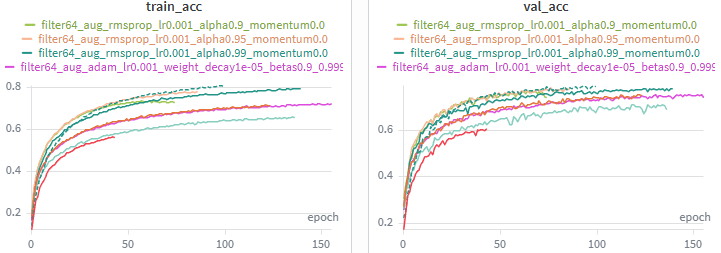

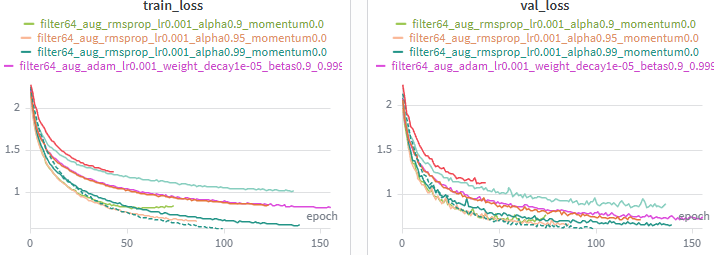

For our Optimizer experiment we tested Adam and RMSProp, since SGD with momentum already was inplemented with our current best Model.
For Adam and RMSProp we again only changed one value at a time, because of GPU limits we only tested 3 different **weight decays** for Adam and 3 different **alphas** for Adam.
In our case we got the best performance by using SGD with momentum = 0.9 and lr = 0.02


# Final Model

## load Dataset with full size

In [24]:
transform_full = transforms.Compose([
    transforms.ToTensor()
])

train_data_full = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform_full
)

In [25]:
loader = DataLoader(train_data_full, batch_size=64, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
total_samples = 0

for images, _ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)  
    mean += images.mean(dim=2).sum(dim=0)
    std += images.std(dim=2).sum(dim=0)
    total_samples += batch_size

mean /= total_samples
std /= total_samples
print(f"Mean: {mean}")
print(f"Std:  {std}")

Mean: tensor([0.4966, 0.4792, 0.3941])
Std:  tensor([0.2191, 0.2158, 0.2195])


In [26]:
transform_full = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

transform_augmented_full = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

train_data_full = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform_full
)

train_data_augmented_full = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/train",
    transform=transform_augmented_full
)

val_data_full = datasets.ImageFolder(
    root="icosimal_img_class_03/data_uniform_224_224_sets/validate",
    transform=transform_full
)

In [27]:
print("Train samples:", len(train_data_full))
print("Val samples:", len(val_data_full))
print(train_data_full.classes)

Train samples: 24000
Val samples: 6000
['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']


In [28]:
image, label = train_data_full[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 0


In [29]:
print("Min pixel value:", image.min())
print("Max pixel value:", image.max())

Min pixel value: tensor(-2.2667)
Max pixel value: tensor(2.7598)


C:\Users\leand\AppData\Local\Temp\ipykernel_21956\243498538.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean_t = torch.tensor(mean).view(3, 1, 1)
C:\Users\leand\AppData\Local\Temp\ipykernel_21956\243498538.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std_t = torch.tensor(std).view(3, 1, 1)


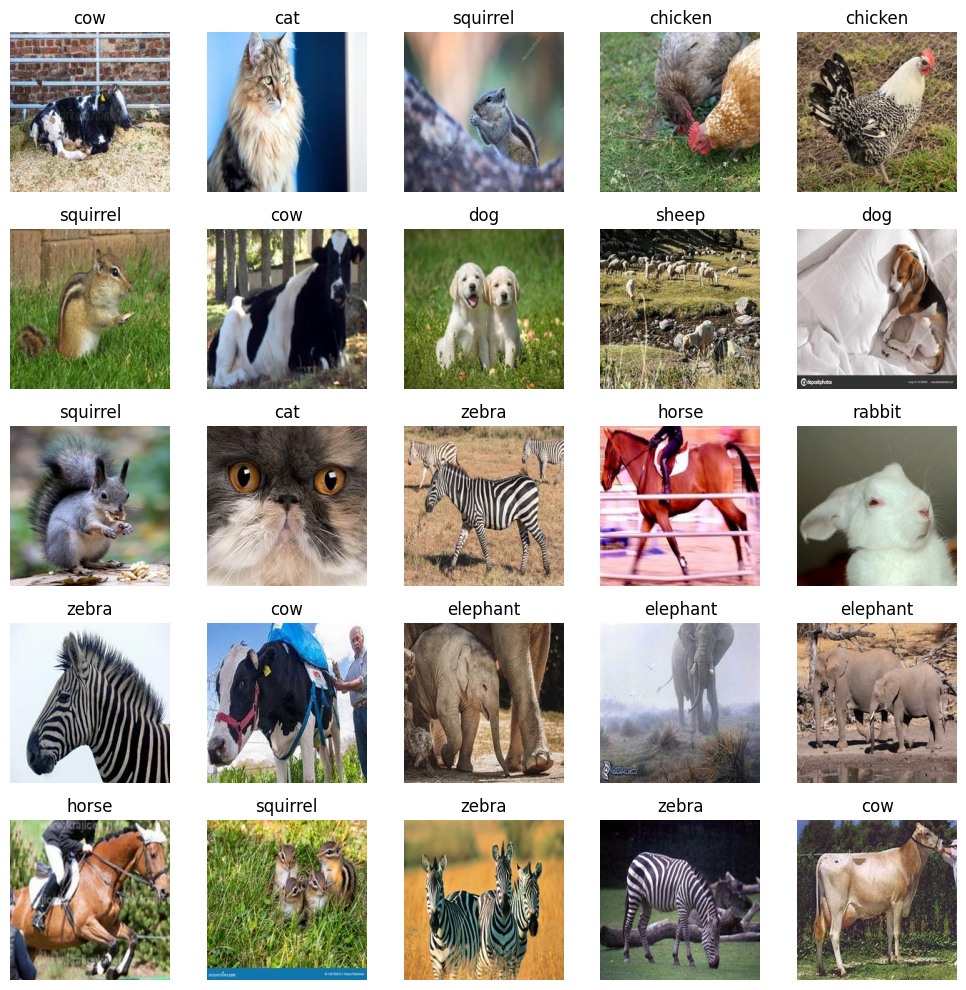

In [30]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

loader = DataLoader(train_data_full, batch_size=25, shuffle=True)
images, labels = next(iter(loader))

# denormalize
mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)
images_denorm = images * std_t + mean_t
images_denorm = images_denorm.clamp(0, 1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i in range(25):
    img = images_denorm[i].permute(1, 2, 0)

    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(train_data_full.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
run_configs = [
    {"name": "Model_full",         "lr": 0.02,  "filters": 64, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0}
]

for cfg in run_configs:
    train_data_used = train_data_augmented_full if cfg["augmented"] else train_data_full

    wandb.init(
        project="PW01",
        name=cfg["name"],
        config={
            **cfg,
            "momentum":     0.9,
            "batch_size":   64,
            "epochs":       200,
            "min_delta":    0.0,
            "patience":     10,
            "units":        128,
        }
    )

    config = wandb.config

    model = deepModel_drop(
        units=config["units"],
        filter=config["filters"],
        dropout_conv=config["dropout_conv"],
        dropout_fc=config["dropout_fc"]
    )

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=cfg["weight_decay"]
    )

    train_eval(model, optimizer, config["epochs"], config["batch_size"],
               train_data_used, val_data_full, device,
               patience=config["patience"],
               log_wandb=True,
               min_delta=config["min_delta"])

    wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pascal/.netrc.
wandb: Currently logged in as: pascalkern1422 (pascalkern1422-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 2.223731, 0.169042, 2.080594, 0.249333
Epoch 1: 2.040775, 0.259417, 1.976284, 0.293833
Epoch 2: 1.956047, 0.297208, 1.844035, 0.346667
Epoch 3: 1.882535, 0.324167, 1.780362, 0.369500
Epoch 4: 1.812607, 0.349250, 1.726698, 0.401333
Epoch 5: 1.759889, 0.371792, 1.670700, 0.404667
Epoch 6: 1.706571, 0.393292, 1.574229, 0.440667
Epoch 7: 1.661959, 0.408625, 1.585884, 0.445167
Epoch 8: 1.609402, 0.427208, 1.459407, 0.494000
Epoch 9: 1.560799, 0.441958, 1.496244, 0.487667
Epoch 10: 1.511509, 0.458750, 1.414700, 0.504167
Epoch 11: 1.478382, 0.474250, 1.333181, 0.533833
Epoch 12: 1.455049, 0.486583, 1.303868, 0.558333
Epoch 13: 1.411472, 0.499292, 1.248698, 0.560500
Epoch 14: 1.392208, 0.508250, 1.223135, 0.575833
Epoch 15: 1.357798, 0.519583, 1.277102, 0.553500
Epoch 16: 1.345436, 0.523625, 1.213198, 0.576833
Epoch 17: 1.310997, 0.536500, 1.178863, 0.592333
Epoch 18: 1.299283, 0.544167, 1.145266, 0.593333
Epoch 19: 1.281528, 0.549875, 1.133090, 0.609667
Epoch 20: 1.269201, 0.554708, 

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x741517f23920>> (for post_run_cell), with arguments args (<ExecutionResult object at 7415241a4830, execution_count=20 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7415242778f0, raw_cell="run_configs = [
    {"name": "Model_full",        .." transformed_cell="run_configs = [
    {"name": "Model_full",        .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/pascal/Deeplearning/PW01/MPW01.ipynb#Y121sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

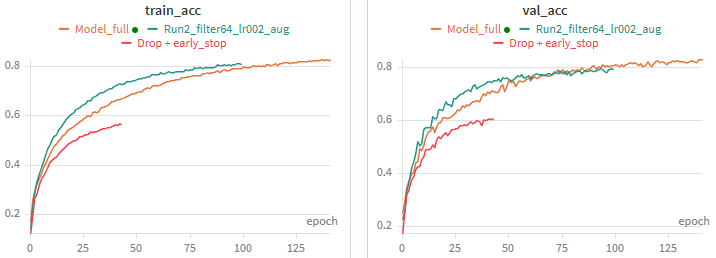

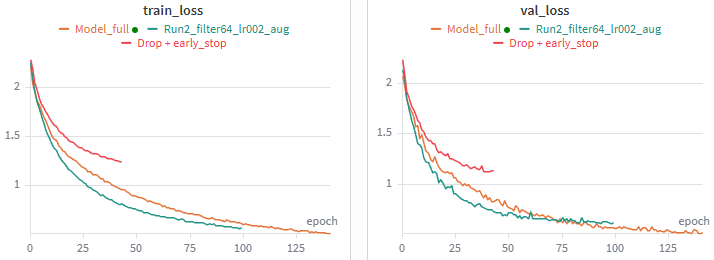

With the same model and the exact same parameters, we observed only a slight improvement when using the full-resolution data. I had expected the improvement to be larger, since even I sometimes struggled to recognise what was shown in the 64×64 images. Therefore, when switching to 224×224, I intuitively assumed that the model performance would increase more significantly. However, the validation accuracy only reached 83%, which is about 4% higher than with 64×64 images. One possible explanation is that, as the input resolution increases, the model may require additional layers to effectively capture and aggregate the more complex spatial information present in higher-resolution images.

## Maybe an Additional Layer helps

In [56]:
class deepModel2_drop(torch.nn.Module):

    def __init__(self, units=128, filter=16, n_classes=10, dropout_conv=0.2, dropout_fc=0.5):
        super(deepModel2_drop, self).__init__()
        self.seq = torch.nn.Sequential(

            # Layer 1
            torch.nn.Conv2d(3, filter, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 2
            torch.nn.Conv2d(filter, filter*2, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 3
            torch.nn.Conv2d(filter*2, filter*4, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Layer 4
            torch.nn.Conv2d(filter*4, filter*8, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            torch.nn.Dropout2d(p=dropout_conv),

            # Flatten and Dense
            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            torch.nn.Linear(filter*8, units),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_fc),

            # Output
            torch.nn.Linear(units, n_classes)
        )

    def forward(self, x):
        return self.seq(x)

In [57]:
model = deepModel2_drop().to(device)
from torchsummary import summary
summary(model, (3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             448
              ReLU-2         [-1, 16, 224, 224]               0
         MaxPool2d-3         [-1, 16, 112, 112]               0
         Dropout2d-4         [-1, 16, 112, 112]               0
            Conv2d-5         [-1, 32, 112, 112]           4,640
              ReLU-6         [-1, 32, 112, 112]               0
         MaxPool2d-7           [-1, 32, 56, 56]               0
         Dropout2d-8           [-1, 32, 56, 56]               0
            Conv2d-9           [-1, 64, 56, 56]          18,496
             ReLU-10           [-1, 64, 56, 56]               0
        MaxPool2d-11           [-1, 64, 28, 28]               0
        Dropout2d-12           [-1, 64, 28, 28]               0
           Conv2d-13          [-1, 128, 28, 28]          73,856
             ReLU-14          [-1, 128,

In [58]:
run_configs = [
    {"name": "Model_full_4L_s",         "lr": 0.02,  "filters": 64, "dropout_conv": 0.1,  "dropout_fc": 0.3,  "augmented": True, "weight_decay": 0}
]

for cfg in run_configs:
    train_data_used = train_data_augmented_full if cfg["augmented"] else train_data_full

    wandb.init(
        project="PW01",
        name=cfg["name"],
        config={
            **cfg,
            "momentum":     0.9,
            "batch_size":   64,
            "epochs":       200,
            "min_delta":    0.0,
            "patience":     10,
            "units":        128,
        }
    )

    config = wandb.config

    model = deepModel2_drop(
        units=config["units"],
        filter=config["filters"],
        dropout_conv=config["dropout_conv"],
        dropout_fc=config["dropout_fc"]
    )

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=cfg["weight_decay"]
    )

    train_eval(model, optimizer, config["epochs"], config["batch_size"],
               train_data_used, val_data_full, device,
               patience=config["patience"],
               log_wandb=True,
               min_delta=config["min_delta"])

    wandb.finish()

Epoch 0: 2.214261, 0.167250, 2.064612, 0.228167
Epoch 1: 2.027207, 0.258583, 1.957051, 0.306000
Epoch 2: 1.929068, 0.307208, 1.843459, 0.324333
Epoch 3: 1.836687, 0.338708, 1.726100, 0.394833
Epoch 4: 1.749381, 0.367375, 1.619938, 0.411167
Epoch 5: 1.669926, 0.397500, 1.572082, 0.425333
Epoch 6: 1.614770, 0.418583, 1.475661, 0.473167
Epoch 7: 1.533881, 0.447750, 1.481383, 0.479667
Epoch 8: 1.469117, 0.471917, 1.364361, 0.530000
Epoch 9: 1.425068, 0.493292, 1.348588, 0.514333
Epoch 10: 1.363819, 0.513792, 1.214436, 0.570000
Epoch 11: 1.320910, 0.533000, 1.152645, 0.586000
Epoch 12: 1.272317, 0.553292, 1.184189, 0.583833
Epoch 13: 1.226430, 0.567583, 1.105214, 0.611667
Epoch 14: 1.198365, 0.580208, 1.030217, 0.627500
Epoch 15: 1.158835, 0.593500, 1.040968, 0.626000
Epoch 16: 1.119673, 0.608667, 1.003595, 0.642000
Epoch 17: 1.077421, 0.622333, 0.912830, 0.686667
Epoch 18: 1.053497, 0.628458, 0.988946, 0.648000
Epoch 19: 1.033722, 0.642042, 0.895536, 0.688333
Epoch 20: 0.982983, 0.661625, 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 97: 0.207360, 0.931208, 0.431111, 0.878500
Early stopping triggered at epoch 97.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█
train_acc,▁▂▃▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████
train_loss,█▇▇▇▆▆▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▃▄▄▄▅▅▇▇▇▇▇▇████████████████████████
val_loss,█▇▇▆▆▅▄▄▄▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,97
train_acc,0.93121
train_loss,0.20736
val_acc,0.8785
val_loss,0.43111


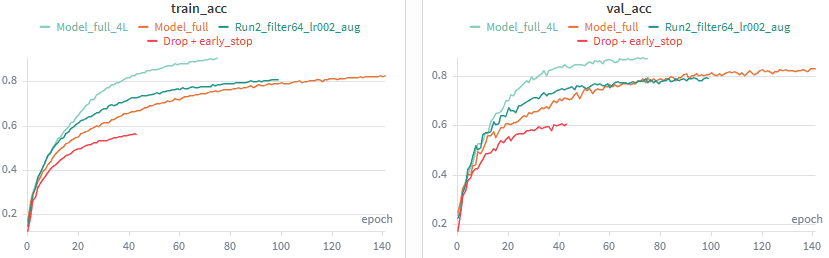

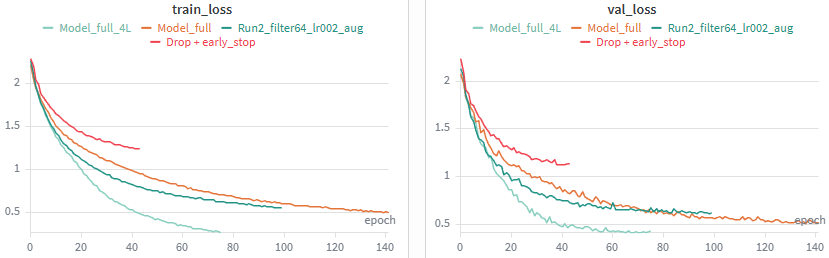


With an additional Layer we were able to achive a Validation accuracy of 87%, a slight improvement of 4% compared to our Model with just 4 Layers.

## Transfer Learning

### ResNet18

In [48]:
from torchvision import models
print(models.resnet18)

<function resnet18 at 0x0000027ACE69BEC0>


In [53]:
run_configs = [
    {"name": "ResNet18_transfer", "lr": 0.01, "augmented": True, "weight_decay": 0}
]

for cfg in run_configs:
    train_data_used = train_data_augmented_full if cfg["augmented"] else train_data_full
    
    wandb.init(
        project="PW01",
        name=cfg["name"],
        config={
            **cfg,
            "momentum": 0.9,
            "batch_size": 64,
            "epochs": 200,
            "min_delta": 0.0,
            "patience": 10,
        }
    )
    config = wandb.config
    
    model = models.resnet18(pretrained=True)
    # ResNet was trained on 1'000 Classes, we only have 10. Therefore, we adjust the output layer:
    model.fc = torch.nn.Linear(model.fc.in_features, 10)

    # Freeze the pretrained layers:
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(device)    
    
    optimizer = torch.optim.SGD(
        params=filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=cfg["weight_decay"]
    )
    
    train_eval(
        model, optimizer,
        config["epochs"], config["batch_size"],
        train_data_used, val_data_full, device,
        patience=config["patience"],
        log_wandb=True,
        min_delta=config["min_delta"]
    )

    wandb.finish()

c:\Users\leand\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\leand\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 0: 0.358031, 0.882875, 0.229315, 0.922333
Epoch 1: 0.244986, 0.916833, 0.217585, 0.926667
Epoch 2: 0.231333, 0.922083, 0.203762, 0.933500
Epoch 3: 0.220615, 0.924292, 0.208634, 0.932333
Epoch 4: 0.220796, 0.925542, 0.206229, 0.929667
Epoch 5: 0.209000, 0.929917, 0.200096, 0.934667
Epoch 6: 0.213059, 0.929833, 0.207275, 0.932667
Epoch 7: 0.212249, 0.928625, 0.204109, 0.931667
Epoch 8: 0.199707, 0.931750, 0.225589, 0.924667
Epoch 9: 0.200888, 0.932208, 0.202652, 0.933000
Epoch 10: 0.203226, 0.932458, 0.219922, 0.926833
Epoch 11: 0.195428, 0.931833, 0.214993, 0.928333
Epoch 12: 0.196036, 0.931458, 0.208661, 0.932833
Epoch 13: 0.191382, 0.935333, 0.202693, 0.935333
Epoch 14: 0.195597, 0.933792, 0.212933, 0.931333


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 15: 0.191384, 0.934542, 0.250778, 0.921000
Early stopping triggered at epoch 15.


epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
train_acc,▁▆▆▇▇▇▇▇████▇███
train_loss,█▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▂▄▇▇▅█▇▆▃▇▄▅▇█▆▁
val_loss,▅▃▂▂▂▁▂▂▅▁▄▃▂▁▃█
epoch,15
train_acc,0.93454
train_loss,0.19138
val_acc,0.921
val_loss,0.25078


### MobileNetV2

In [54]:
print(models.mobilenet_v2)

<function mobilenet_v2 at 0x0000027ACE698400>


In [55]:
run_configs = [
    {"name": "MobileNetV2_transfer", "lr": 0.01, "augmented": True, "weight_decay": 0}
]

for cfg in run_configs:
    train_data_used = train_data_augmented_full if cfg["augmented"] else train_data_full

    wandb.init(
        project="PW01",
        name=cfg["name"],
        config={
            **cfg,
            "momentum": 0.9,
            "batch_size": 64,
            "epochs": 200,
            "min_delta": 0.0,
            "patience": 10,
        }
    )
    config = wandb.config

    model = models.mobilenet_v2(pretrained=True)
    # Adjust number of output layers
    model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 10)

    # Freeze pretrained layers
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    model = model.to(device)

    optimizer = torch.optim.SGD(
        params=filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"],
        momentum=config["momentum"],
        weight_decay=config["weight_decay"]
    )

    train_eval(
        model, optimizer,
        config["epochs"], config["batch_size"],
        train_data_used, val_data_full, device,
        patience=config["patience"],
        log_wandb=True,
        min_delta=config["min_delta"]
    )

    wandb.finish()

c:\Users\leand\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\leand\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\leand/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 60.9MB/s]


Epoch 0: 0.370083, 0.879500, 0.215308, 0.925333
Epoch 1: 0.253790, 0.914417, 0.204084, 0.931667
Epoch 2: 0.240280, 0.918958, 0.207498, 0.929833
Epoch 3: 0.232506, 0.920833, 0.199873, 0.932500
Epoch 4: 0.228741, 0.921667, 0.204627, 0.930000
Epoch 5: 0.229317, 0.921875, 0.195140, 0.933500
Epoch 6: 0.217253, 0.926542, 0.199431, 0.929500
Epoch 7: 0.227079, 0.922042, 0.186099, 0.938167
Epoch 8: 0.219767, 0.924208, 0.197172, 0.934833
Epoch 9: 0.215098, 0.927000, 0.194592, 0.935333
Epoch 10: 0.225012, 0.922792, 0.199221, 0.932333
Epoch 11: 0.225833, 0.922625, 0.189282, 0.935500
Epoch 12: 0.216116, 0.925750, 0.198224, 0.933000
Epoch 13: 0.220593, 0.926083, 0.191297, 0.938000
Epoch 14: 0.206951, 0.928250, 0.194021, 0.936833
Epoch 15: 0.216321, 0.926542, 0.185024, 0.939167
Epoch 16: 0.217677, 0.924958, 0.193929, 0.934500
Epoch 17: 0.211955, 0.926875, 0.189029, 0.936000
Epoch 18: 0.212317, 0.927167, 0.190222, 0.936000
Epoch 19: 0.216759, 0.926000, 0.203746, 0.931500
Epoch 20: 0.214969, 0.926875, 

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 25: 0.213989, 0.925208, 0.185743, 0.940833
Early stopping triggered at epoch 25.


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_acc,▁▆▇▇▇▇█▇▇█▇▇▇███▇████████▇
train_loss,█▃▂▂▂▂▁▂▂▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▃▄▃▅▃▇▅▆▄▆▄▇▆▇▅▆▆▄▆▅▄▆▆█
val_loss,█▅▆▄▆▃▄▁▄▃▄▂▄▂▃▁▃▂▂▅▂▄▄▃▂▁
epoch,25
train_acc,0.92521
train_loss,0.21399
val_acc,0.94083
val_loss,0.18574


For transfer learning, we selected two well-established pre-trained models:
- ResNet18
- MobileNetV2

For both experiments, we used the hyperparameters of our best "from-scratch" model. Additionally, we froze the pre-trained layers and only trained the newly added classification layer.

<img src="images/translrn_val_loss.png" width="45%">
<img src="images/translrn_val_acc.png" width="45%">

Both transfer learning models performed very well and converged extremely quickly due to the pre-trained feature representations:
- The ResNet18 model trained for 15 epochs before early stopping was triggered.
- The MobileNetV2 model trained for 25 epochs before early stopping was triggered.

As expected, both transfer learning models outperformed our "from-scratch" model:
- "From-scratch" model: ~0.88 acc / ~0.43 loss.
- ResNet18: ~0.92 acc / ~0.25 loss.
- MobileNetV2: ~0.94 acc / ~0.19 loss.
In addition to achieving better performance, the transfer learning models required significantly fewer training epochs. Nevertheless, the "from-scratch" model still achieved strong performance.